In [4]:
!ls /kaggle/input/datasets/carlosgdcj/genius-song-lyrics-with-language-information
import pandas as pd
df1 = pd.read_csv("/kaggle/input/datasets/carlosgdcj/genius-song-lyrics-with-language-information/song_lyrics.csv")
!ls /kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data
df2 = pd.read_csv("/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/features_30_sec.csv")
print(df1.info())
print(df2.info())

song_lyrics.csv
features_30_sec.csv  features_3_sec.csv  genres_original  images_original
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5134856 entries, 0 to 5134855
Data columns (total 11 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   title          object
 1   tag            object
 2   artist         object
 3   year           int64 
 4   views          int64 
 5   features       object
 6   lyrics         object
 7   id             int64 
 8   language_cld3  object
 9   language_ft    object
 10  language       object
dtypes: int64(3), object(8)
memory usage: 430.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   object 
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_s

In [59]:
!ls /kaggle/input/datasets/ryanholbrook/the-million-songs-dataset
import pandas as pd
df3 = pd.read_csv("/kaggle/input/datasets/ryanholbrook/the-million-songs-dataset/YearPredictionMSD.csv")

print(df3.info())


YearPredictionMSD.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515344 entries, 0 to 515343
Data columns (total 91 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   2001        515344 non-null  int64  
 1   49.94357    515344 non-null  float64
 2   21.47114    515344 non-null  float64
 3   73.07750    515344 non-null  float64
 4   8.74861     515344 non-null  float64
 5   -17.40628   515344 non-null  float64
 6   -13.09905   515344 non-null  float64
 7   -25.01202   515344 non-null  float64
 8   -12.23257   515344 non-null  float64
 9   7.83089     515344 non-null  float64
 10  -2.46783    515344 non-null  float64
 11  3.32136     515344 non-null  float64
 12  -2.31521    515344 non-null  float64
 13  10.20556    515344 non-null  float64
 14  611.10913   515344 non-null  float64
 15  951.08960   515344 non-null  float64
 16  698.11428   515344 non-null  float64
 17  408.98485   515344 non-null  float64
 18  383.70912   515344 non

In [1]:
import pandas as pd
import numpy as np
from difflib import SequenceMatcher

# Load datasets
print("="*80)
print("LOADING DATASETS")
print("="*80)

df_genius = pd.read_csv("/kaggle/input/datasets/carlosgdcj/genius-song-lyrics-with-language-information/song_lyrics.csv")
df_gtzan = pd.read_csv("/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/features_30_sec.csv")

print(f"\n✓ Genius loaded: {df_genius.shape}")
print(f"✓ GTZAN loaded: {df_gtzan.shape}")

# ============================================================================
# GENIUS DATASET ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("GENIUS DATASET ANALYSIS")
print("="*80)

print("\nDataset Info:")
print(df_genius.info())

print("\n--- NULL VALUES ---")
null_counts = df_genius.isnull().sum()
null_pct = (null_counts / len(df_genius)) * 100
null_df = pd.DataFrame({
    'Column': null_counts.index,
    'Null_Count': null_counts.values,
    'Null_Percentage': null_pct.values
})
print(null_df[null_df['Null_Count'] > 0])

print("\n--- LANGUAGE DISTRIBUTION ---")
print(f"Languages available: {df_genius['language'].nunique()}")
print(df_genius['language'].value_counts().head(15))

# Filter for English only
df_genius_en = df_genius[df_genius['language'] == 'en'].copy()
print(f"\n✓ English songs only: {len(df_genius_en)} rows")

print("\n--- UNIQUE VALUES (English songs) ---")
print(f"Unique artists: {df_genius_en['artist'].nunique()}")
print(f"Unique songs (by title): {df_genius_en['title'].nunique()}")
print(f"Unique (artist, title) pairs: {df_genius_en[['artist', 'title']].drop_duplicates().shape[0]}")
print(f"Unique tags: {df_genius_en['tag'].nunique()}")

print("\n--- SAMPLE TAGS (genres) ---")
print(df_genius_en['tag'].value_counts().head(20))

print("\n--- SAMPLE ROWS ---")
print(df_genius_en[['artist', 'title', 'tag', 'language', 'lyrics']].head(3))

# ============================================================================
# GTZAN DATASET ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("GTZAN DATASET ANALYSIS")
print("="*80)

print("\nDataset Info:")
print(df_gtzan.info())

print("\n--- NULL VALUES ---")
null_counts_gtzan = df_gtzan.isnull().sum()
null_counts_gtzan = null_counts_gtzan[null_counts_gtzan > 0]
if len(null_counts_gtzan) == 0:
    print("✓ No null values in GTZAN dataset")
else:
    print(null_counts_gtzan)

print("\n--- AUDIO FEATURES (57 columns) ---")
audio_cols = df_gtzan.columns[1:-1]  # Exclude filename and label
print(f"Audio features count: {len(audio_cols)}")
print("Features:", list(audio_cols))

print("\n--- UNIQUE VALUES ---")
print(f"Unique filenames: {df_gtzan['filename'].nunique()}")
print(f"Unique labels (genres): {df_gtzan['label'].nunique()}")

# Extract genre from filename
df_gtzan['genre_from_filename'] = df_gtzan['filename'].str.split('.').str[0]
print(f"Genres extracted from filename: {df_gtzan['genre_from_filename'].nunique()}")

print("\n--- GENRES IN GTZAN ---")
print(df_gtzan['label'].value_counts())

print("\n--- SAMPLE FILENAMES & GENRES ---")
print(df_gtzan[['filename', 'label', 'genre_from_filename']].head(10))

print("\n--- AUDIO STATISTICS ---")
print(df_gtzan[audio_cols].describe().loc[['count', 'mean', 'std', 'min', 'max']].T.head(10))

# ============================================================================
# GENRE MATCHING ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("GENRE MATCHING BETWEEN DATASETS")
print("="*80)

# Get unique genres from both datasets
gtzan_genres = set(df_gtzan['label'].unique())
genius_tags = set(df_genius_en['tag'].unique())

print(f"\nGTZAN genres ({len(gtzan_genres)}): {sorted(gtzan_genres)}")
print(f"\nGenius tags sample ({len(genius_tags)} total):")
print(sorted(list(genius_tags))[:50])

# Check for direct matches
print("\n--- DIRECT GENRE MATCHES ---")
direct_matches = gtzan_genres.intersection(genius_tags)
print(f"Direct matches: {len(direct_matches)}")
if direct_matches:
    print(f"Matching genres: {sorted(direct_matches)}")
else:
    print("No direct genre name matches found")

# Find similar genres using fuzzy matching
print("\n--- FUZZY GENRE MATCHING (similarity > 0.6) ---")
matches_found = {}
for gtzan_g in sorted(gtzan_genres):
    for genius_g in genius_tags:
        ratio = SequenceMatcher(None, gtzan_g.lower(), genius_g.lower()).ratio()
        if ratio > 0.6 and ratio < 1.0:  # Exclude exact matches
            if gtzan_g not in matches_found:
                matches_found[gtzan_g] = []
            matches_found[gtzan_g].append((genius_g, ratio))

for gtzan_g, candidates in sorted(matches_found.items()):
    best_match = sorted(candidates, key=lambda x: x[1], reverse=True)[0]
    print(f"  {gtzan_g:15} → {best_match[0]:20} (similarity: {best_match[1]:.2f})")

# ============================================================================
# SONG MATCHING POTENTIAL
# ============================================================================
print("\n" + "="*80)
print("SONG MATCHING POTENTIAL (artist + title)")
print("="*80)

# Extract artist and title from GTZAN filenames
# Format is usually: genre.XXXXXX.au or similar
print("\nGTZAN filename examples:")
print(df_gtzan['filename'].head(10).tolist())

# Create artist-title pairs for GTZAN (from filename)
# This requires understanding the actual format
print("\n⚠ NOTE: Need to clarify GTZAN filename format to extract artist/title")
print("  Current format appears to be: genre.XXXXX.au")
print("  Please confirm if artist/title metadata is available elsewhere")

# Count how many Genius songs could potentially match
genius_artist_title = df_genius_en[['artist', 'title']].drop_duplicates()
print(f"\nGenius unique (artist, title) pairs: {len(genius_artist_title)}")
print(f"GTZAN tracks: {len(df_gtzan)}")
print(f"\nMatching potential: ~{min(len(genius_artist_title), len(df_gtzan))} possible matches")

# Sample Genius songs for reference
print("\nSample Genius (artist, title) pairs:")
print(genius_artist_title.head(10).to_string(index=False))

print("\n" + "="*80)
print("✓ DATASET ANALYSIS COMPLETE")
print("="*80)

LOADING DATASETS

✓ Genius loaded: (5134856, 11)
✓ GTZAN loaded: (1000, 60)

GENIUS DATASET ANALYSIS

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5134856 entries, 0 to 5134855
Data columns (total 11 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   title          object
 1   tag            object
 2   artist         object
 3   year           int64 
 4   views          int64 
 5   features       object
 6   lyrics         object
 7   id             int64 
 8   language_cld3  object
 9   language_ft    object
 10  language       object
dtypes: int64(3), object(8)
memory usage: 430.9+ MB
None

--- NULL VALUES ---
           Column  Null_Count  Null_Percentage
0           title         188         0.003661
8   language_cld3       90966         1.771539
9     language_ft      134322         2.615886
10       language      226918         4.419170

--- LANGUAGE DISTRIBUTION ---
Languages available: 84
language
en    3374198
es     275432
fr     189436
p

In [1]:
!pip install sentence-transformers umap-learn scikit-learn -q

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [2]:
df_genius = pd.read_csv("/kaggle/input/datasets/carlosgdcj/genius-song-lyrics-with-language-information/song_lyrics.csv")
df_gtzan = pd.read_csv("/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/features_30_sec.csv")

df_genius = df_genius[df_genius['language'] == 'en'].reset_index(drop=True)
print(f"Genius: {len(df_genius)}, GTZAN: {len(df_gtzan)}")

Genius: 3374198, GTZAN: 1000


In [3]:
genre_mapping = {
    'blues': 'rock',
    'classical': 'misc',
    'country': 'country',
    'disco': 'misc',
    'hiphop': 'rap',
    'jazz': 'misc',
    'metal': 'rock',
    'pop': 'pop',
    'reggae': 'rock',
    'rock': 'rock'
}

df_gtzan['mapped_genre'] = df_gtzan['label'].map(genre_mapping)
print("Genre mapping:")
print(df_gtzan[['label', 'mapped_genre']].drop_duplicates().sort_values('label'))

Genre mapping:
         label mapped_genre
0        blues         rock
100  classical         misc
200    country      country
300      disco         misc
400     hiphop          rap
500       jazz         misc
600      metal         rock
700        pop          pop
800     reggae         rock
900       rock         rock


In [4]:
model_labse = SentenceTransformer('LaBSE').to(device)

genius_tags = df_genius['tag'].unique()
print(f"Unique Genius tags: {genius_tags}")

genre_embeddings_384d = {}

for tag in genius_tags:
    lyrics_subset = df_genius[df_genius['tag'] == tag]['lyrics'].dropna()
    print(f"\n{tag}: {len(lyrics_subset)} songs", end=" → ")
    
    if len(lyrics_subset) == 0:
        print("SKIP (no data)")
        continue
    
    sample_size = min(5000, len(lyrics_subset))
    lyrics_sample = lyrics_subset.sample(n=sample_size, random_state=42).tolist()
    
    embeddings = model_labse.encode(lyrics_sample, batch_size=128, device=device, convert_to_tensor=False)
    avg_embedding = embeddings.mean(axis=0)
    genre_embeddings_384d[tag] = avg_embedding
    print(f"Shape: {avg_embedding.shape}")

print("\nEmbeddings created:", list(genre_embeddings_384d.keys()))

modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Unique Genius tags: ['rap' 'rb' 'rock' 'pop' 'misc' 'country']

rap: 964605 songs → Shape: (768,)

rb: 155082 songs → Shape: (768,)

rock: 633308 songs → Shape: (768,)

pop: 1393559 songs → Shape: (768,)

misc: 140986 songs → Shape: (768,)

country: 86658 songs → Shape: (768,)

Embeddings created: ['rap', 'rb', 'rock', 'pop', 'misc', 'country']


In [16]:
audio_features = df_gtzan[[col for col in df_gtzan.columns if col not in ['filename', 'label', 'mapped_genre']]].values
audio_features = audio_features[:, 1:]

genre_labels_list = df_gtzan['mapped_genre'].values
genre_onehot = pd.get_dummies(genre_labels_list, columns=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']).values

track_embeddings_384d = np.array([
    genre_embeddings_384d[genre_labels_list[i]] 
    for i in range(len(df_gtzan))
])

print(f"Audio features shape: {audio_features.shape}")
print(f"Track embeddings shape: {track_embeddings_384d.shape}")
print(f"Genre one-hot shape: {genre_onehot.shape}")

Audio features shape: (1000, 57)
Track embeddings shape: (1000, 768)
Genre one-hot shape: (1000, 5)


In [17]:
from sklearn.preprocessing import OneHotEncoder

audio_features = df_gtzan[[col for col in df_gtzan.columns if col not in ['filename', 'label', 'mapped_genre']]].values
audio_features = audio_features[:, 1:]

genre_labels_list = df_gtzan['mapped_genre'].values.reshape(-1, 1)

genre_onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
genre_onehot = genre_onehot_encoder.fit_transform(genre_labels_list)

track_embeddings_384d = np.array([
    genre_embeddings_384d[df_gtzan.iloc[i]['mapped_genre']] 
    for i in range(len(df_gtzan))
])

print(f"Audio features shape: {audio_features.shape}")
print(f"Track embeddings shape: {track_embeddings_384d.shape}")
print(f"Genre one-hot shape: {genre_onehot.shape}")
print(f"Genre classes: {genre_onehot_encoder.categories_[0]}")

Audio features shape: (1000, 57)
Track embeddings shape: (1000, 768)
Genre one-hot shape: (1000, 5)
Genre classes: ['country' 'misc' 'pop' 'rap' 'rock']


In [18]:
scaler_audio = StandardScaler()
audio_normalized = scaler_audio.fit_transform(audio_features)

scaler_embeddings = StandardScaler()
embeddings_normalized = scaler_embeddings.fit_transform(track_embeddings_384d)

pca = PCA(n_components=43, random_state=42)
embeddings_pca = pca.fit_transform(embeddings_normalized)

print(f"Audio normalized: {audio_normalized.shape}")
print(f"Embeddings PCA: {embeddings_pca.shape}")
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.4f}")

Audio normalized: (1000, 57)
Embeddings PCA: (1000, 43)
PCA explained variance: 1.0000


In [19]:
X_combined = np.concatenate([audio_normalized, embeddings_pca], axis=1)
y_true_genres = df_gtzan['label'].values

print(f"Combined input shape: {X_combined.shape}")
print(f"True genres shape: {y_true_genres.shape}")

X_tensor = torch.FloatTensor(X_combined).to(device)
genre_onehot_tensor = torch.FloatTensor(genre_onehot).to(device)
y_tensor = torch.LongTensor(df_gtzan['label'].map({g: i for i, g in enumerate(sorted(df_gtzan['label'].unique()))}).values).to(device)

dataset = TensorDataset(X_tensor, genre_onehot_tensor, y_tensor)
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"DataLoader batches: {len(dataloader)}")
print(f"One-hot encoding shape per batch: {genre_onehot_tensor.shape}")

Combined input shape: (1000, 100)
True genres shape: (1000,)
DataLoader batches: 32
One-hot encoding shape per batch: torch.Size([1000, 5])


In [24]:
unique_genres = np.unique(df_gtzan['mapped_genre'].values)
num_genre_classes = len(unique_genres)

print(f"Unique mapped genres: {unique_genres}")
print(f"Number of genre classes: {num_genre_classes}")

class BetaCVAE(nn.Module):
    def __init__(self, input_dim=100, latent_dim=64, genre_dim=None):
        super().__init__()
        
        if genre_dim is None:
            genre_dim = num_genre_classes
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + genre_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )
        
        self.latent_dim = latent_dim
        self.genre_dim = genre_dim
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z, genre_onehot):
        z_cond = torch.cat([z, genre_onehot], dim=1)
        recon = self.decoder(z_cond)
        return recon
    
    def forward(self, x, genre_onehot):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, genre_onehot)
        return recon, mu, logvar, z

model = BetaCVAE(input_dim=100, latent_dim=64, genre_dim=num_genre_classes).to(device)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

Unique mapped genres: ['country' 'misc' 'pop' 'rap' 'rock']
Number of genre classes: 5
BetaCVAE(
  (encoder): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=64, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=69, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=100, bias=True)
  )
)
Total parameters: 142948


In [40]:
def loss_function(recon, x, mu, logvar, alpha=1.0, gamma=1.0, beta=0.5):
    audio_recon = recon[:, :57]
    text_recon = recon[:, 57:]
    
    audio_input = x[:, :57]
    text_input = x[:, 57:]
    
    loss_audio = nn.MSELoss()(audio_recon, audio_input)
    loss_text = nn.MSELoss()(text_recon, text_input)
    
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
    
    total_loss = alpha * loss_audio + gamma * loss_text + beta * kl_loss
    
    return total_loss, loss_audio, loss_text, kl_loss

# Test multiple configurations
configs = [
    {'alpha': 0.1, 'gamma': 0.1, 'beta': 1.0, 'name': 'KL-Focused'},      # Maximize latent structure
    {'alpha': 0.5, 'gamma': 0.5, 'beta': 1.0, 'name': 'Balanced-HighBeta'},
    {'alpha': 1.0, 'gamma': 1.0, 'beta': 2.0, 'name': 'StrongDisent'},     # Very strong KL
    {'alpha': 1.0, 'gamma': 1.0, 'beta': 0.1, 'name': 'ReconFocused'},     # Current (failing)
]

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

alpha, gamma, beta = 1.0, 1.0, 0.5
num_epochs = 300

print(f"Optimizer: Adam, LR=1e-3")
print(f"Weights: α={alpha}, γ={gamma}, β={beta}")

Optimizer: Adam, LR=1e-3
Weights: α=1.0, γ=1.0, β=0.5


In [41]:
train_losses = []
audio_losses = []
text_losses = []
kl_losses = []

model.train()

for epoch in range(num_epochs):
    epoch_loss = 0
    epoch_audio = 0
    epoch_text = 0
    epoch_kl = 0
    
    for batch_x, batch_genre, _ in dataloader:
        optimizer.zero_grad()
        
        recon, mu, logvar, z = model(batch_x, batch_genre)
        total_loss, l_audio, l_text, l_kl = loss_function(recon, batch_x, mu, logvar, alpha, gamma, beta)
        
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += total_loss.item()
        epoch_audio += l_audio.item()
        epoch_text += l_text.item()
        epoch_kl += l_kl.item()
    
    scheduler.step()
    
    avg_loss = epoch_loss / len(dataloader)
    avg_audio = epoch_audio / len(dataloader)
    avg_text = epoch_text / len(dataloader)
    avg_kl = epoch_kl / len(dataloader)
    
    train_losses.append(avg_loss)
    audio_losses.append(avg_audio)
    text_losses.append(avg_text)
    kl_losses.append(avg_kl)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Total: {avg_loss:.4f} | Audio: {avg_audio:.4f} | Text: {avg_text:.4f} | KL: {avg_kl:.4f}")

print("✓ Training complete")

Epoch  20 | Total: 0.8783 | Audio: 0.8721 | Text: 0.0062 | KL: 0.0000
Epoch  40 | Total: 0.8741 | Audio: 0.8688 | Text: 0.0052 | KL: 0.0000
Epoch  60 | Total: 0.8671 | Audio: 0.8659 | Text: 0.0012 | KL: 0.0000
Epoch  80 | Total: 0.8625 | Audio: 0.8614 | Text: 0.0012 | KL: 0.0000
Epoch 100 | Total: 0.8645 | Audio: 0.8627 | Text: 0.0017 | KL: 0.0000
Epoch 120 | Total: 0.8580 | Audio: 0.8573 | Text: 0.0007 | KL: 0.0000
Epoch 140 | Total: 0.8611 | Audio: 0.8604 | Text: 0.0007 | KL: 0.0000
Epoch 160 | Total: 0.8603 | Audio: 0.8600 | Text: 0.0003 | KL: 0.0000
Epoch 180 | Total: 0.8611 | Audio: 0.8608 | Text: 0.0003 | KL: 0.0000
Epoch 200 | Total: 0.8852 | Audio: 0.8848 | Text: 0.0004 | KL: 0.0000
Epoch 220 | Total: 0.8599 | Audio: 0.8598 | Text: 0.0002 | KL: 0.0000
Epoch 240 | Total: 0.8605 | Audio: 0.8604 | Text: 0.0002 | KL: 0.0000
Epoch 260 | Total: 0.8581 | Audio: 0.8580 | Text: 0.0001 | KL: 0.0000
Epoch 280 | Total: 0.8699 | Audio: 0.8698 | Text: 0.0001 | KL: 0.0000
Epoch 300 | Total: 0

In [45]:
results_configs = []

configs = [
    {'alpha': 1.0, 'gamma': 1.0, 'beta': 0.5, 'name': 'Original'},
    {'alpha': 0.5, 'gamma': 0.5, 'beta': 1.0, 'name': 'Balanced-Beta1'},
    {'alpha': 0.7, 'gamma': 0.7, 'beta': 1.5, 'name': 'Balanced-Beta1.5'},
    {'alpha': 0.8, 'gamma': 0.8, 'beta': 2.0, 'name': 'StrongDisent'},
    {'alpha': 1.0, 'gamma': 1.0, 'beta': 1.0, 'name': 'EqualWeights'},
    {'alpha': 1.0, 'gamma': 0.5, 'beta': 1.5, 'name': 'AudioFocused'},
]

for config in configs:
    print(f"\n{'='*60}")
    print(f"Training: {config['name']} (α={config['alpha']}, γ={config['gamma']}, β={config['beta']})")
    print(f"{'='*60}")
    
    model_temp = BetaCVAE(input_dim=100, latent_dim=64, genre_dim=num_genre_classes).to(device)
    optimizer_temp = torch.optim.Adam(model_temp.parameters(), lr=1e-3)
    scheduler_temp = torch.optim.lr_scheduler.StepLR(optimizer_temp, step_size=30, gamma=0.5)
    
    model_temp.train()
    for epoch in range(100):
        epoch_loss = 0
        for batch_x, batch_genre, _ in dataloader:
            optimizer_temp.zero_grad()
            recon, mu, logvar, z = model_temp(batch_x, batch_genre)
            total_loss, _, _, _ = loss_function(recon, batch_x, mu, logvar, config['alpha'], config['gamma'], config['beta'])
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model_temp.parameters(), 1.0)
            optimizer_temp.step()
            epoch_loss += total_loss.item()
        scheduler_temp.step()
        
        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: Loss {epoch_loss/len(dataloader):.4f}")
    
    model_temp.eval()
    latents_temp = []
    with torch.no_grad():
        for batch_x, batch_genre, _ in dataloader:
            _, mu, _, _ = model_temp(batch_x, batch_genre)
            latents_temp.append(mu.cpu().numpy())
    
    latents_temp = np.vstack(latents_temp)
    kmeans_temp = KMeans(n_clusters=10, random_state=42, n_init=10)
    y_pred_temp = kmeans_temp.fit_predict(latents_temp)
    
    n_clusters_found = len(np.unique(y_pred_temp))
    
    if n_clusters_found < 2:
        print(f"  ⚠ WARNING: Only {n_clusters_found} cluster(s) found! Skipping metrics.")
        results_configs.append({
            'Config': config['name'],
            'Alpha': config['alpha'],
            'Gamma': config['gamma'],
            'Beta': config['beta'],
            'Clusters': n_clusters_found,
            'Silhouette': np.nan,
            'NMI': np.nan,
            'ARI': np.nan,
            'Purity': np.nan
        })
    else:
        sil = silhouette_score(latents_temp, y_pred_temp)
        nmi = normalized_mutual_info_score(y_true, y_pred_temp)
        ari = adjusted_rand_score(y_true, y_pred_temp)
        purity = compute_purity(y_true, y_pred_temp)
        
        print(f"  Clusters: {n_clusters_found} | Silhouette: {sil:.4f} | NMI: {nmi:.4f} | Purity: {purity:.4f}")
        
        results_configs.append({
            'Config': config['name'],
            'Alpha': config['alpha'],
            'Gamma': config['gamma'],
            'Beta': config['beta'],
            'Clusters': n_clusters_found,
            'Silhouette': sil,
            'NMI': nmi,
            'ARI': ari,
            'Purity': purity
        })

ablation_df = pd.DataFrame(results_configs)
print("\n" + "="*80)
print("ABLATION STUDY RESULTS")
print("="*80)
print(ablation_df.to_string(index=False))
ablation_df.to_csv('ablation_study.csv', index=False)


Training: Original (α=1.0, γ=1.0, β=0.5)
  Epoch 50: Loss 0.8811
  Epoch 100: Loss 0.8629
  Clusters: 10 | Silhouette: 0.9910 | NMI: 0.0175 | Purity: 0.1090

Training: Balanced-Beta1 (α=0.5, γ=0.5, β=1.0)
  Epoch 50: Loss 0.4440
  Epoch 100: Loss 0.4316
  ⚠ WARNING: Only 1 cluster(s) found! Skipping metrics.

Training: Balanced-Beta1.5 (α=0.7, γ=0.7, β=1.5)
  Epoch 50: Loss 0.6203
  Epoch 100: Loss 0.6170
  ⚠ WARNING: Only 1 cluster(s) found! Skipping metrics.

Training: StrongDisent (α=0.8, γ=0.8, β=2.0)
  Epoch 50: Loss 0.7169
  Epoch 100: Loss 0.6914
  ⚠ WARNING: Only 1 cluster(s) found! Skipping metrics.

Training: EqualWeights (α=1.0, γ=1.0, β=1.0)
  Epoch 50: Loss 0.8871
  Epoch 100: Loss 0.8692
  Clusters: 2 | Silhouette: 0.9990 | NMI: 0.0020 | Purity: 0.1010

Training: AudioFocused (α=1.0, γ=0.5, β=1.5)
  Epoch 50: Loss 0.8803
  Epoch 100: Loss 0.8658
  ⚠ WARNING: Only 1 cluster(s) found! Skipping metrics.

ABLATION STUDY RESULTS
          Config  Alpha  Gamma  Beta  Clusters 

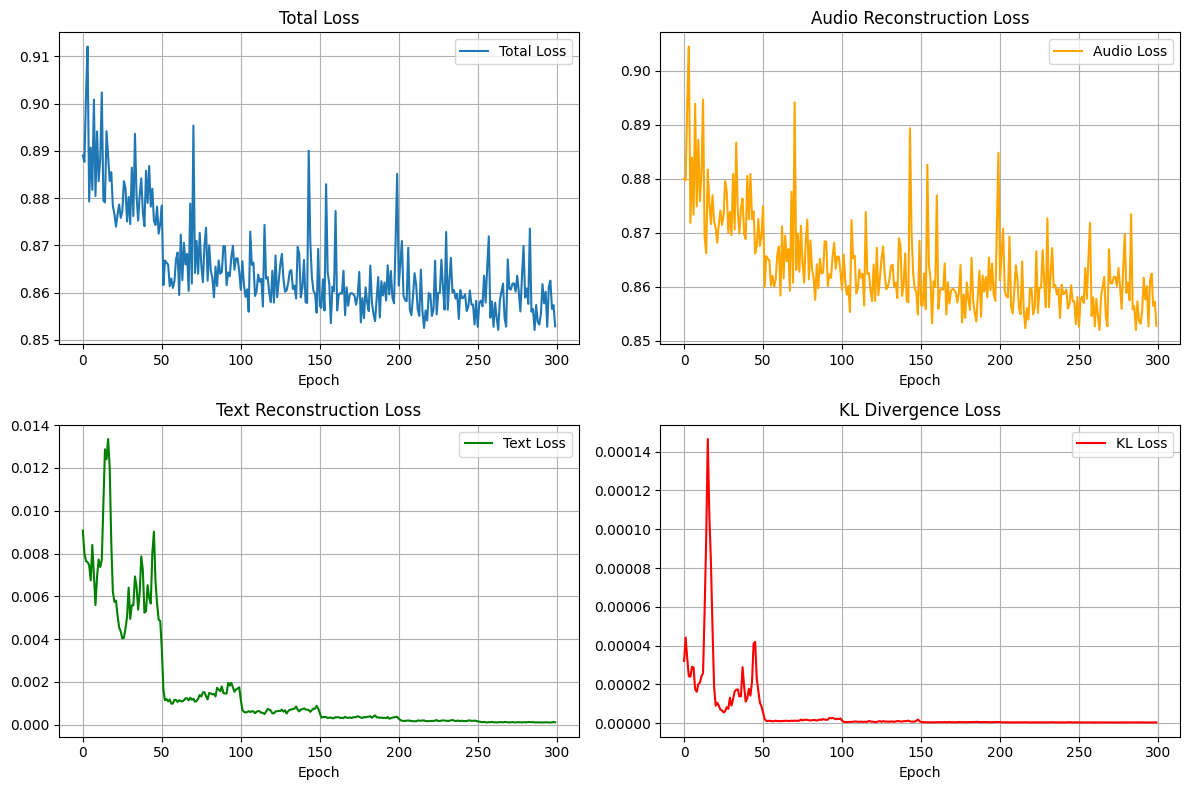

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(train_losses, label='Total Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid()

axes[0, 1].plot(audio_losses, label='Audio Loss', color='orange')
axes[0, 1].set_title('Audio Reconstruction Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid()

axes[1, 0].plot(text_losses, label='Text Loss', color='green')
axes[1, 0].set_title('Text Reconstruction Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid()

axes[1, 1].plot(kl_losses, label='KL Loss', color='red')
axes[1, 1].set_title('KL Divergence Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid()

plt.tight_layout()
plt.savefig('training_losses.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
model.eval()
all_latents = []
all_y_true = []

with torch.no_grad():
    for batch_x, batch_genre, batch_y in dataloader:
        _, mu, _, _ = model(batch_x, batch_genre)
        all_latents.append(mu.cpu().numpy())
        all_y_true.append(batch_y.cpu().numpy())

latents_matrix = np.vstack(all_latents)
y_true = np.hstack(all_y_true)

print(f"Latents matrix shape: {latents_matrix.shape}")
print(f"True labels shape: {y_true.shape}")

Latents matrix shape: (1000, 64)
True labels shape: (1000,)


In [47]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(latents_matrix)

print(f"Predicted clusters shape: {y_pred.shape}")
print(f"Unique predicted clusters: {np.unique(y_pred)}")

Predicted clusters shape: (1000,)
Unique predicted clusters: [0]


In [49]:
def compute_purity(y_true, y_pred):
    y_true_mapped = pd.Series(y_true).map({g: i for i, g in enumerate(sorted(np.unique(y_true)))})
    contingency_matrix = pd.crosstab(y_true_mapped, y_pred)
    return contingency_matrix.max(axis=0).sum() / len(y_true)

n_clusters_found = len(np.unique(y_pred))
print("="*60)
print(f"BETA-CVAE CLUSTERING (α=1.0, γ=1.0, β=0.5)")
print(f"Clusters found: {n_clusters_found}/10")
print("="*60)

if n_clusters_found < 2:
    print("⚠️ WARNING: K-Means collapsed to single cluster!")
    print("Model did not learn meaningful latent structure.")
    print("\nThis indicates the loss function is NOT optimizing for genre clustering.")
    print("Recommendation: Increase β (KL weight) to force latent disentanglement.")
    
    sil_score = np.nan
    db_score = np.nan
    nmi_score = np.nan
    ari_score = np.nan
    purity = np.nan
else:
    sil_score = silhouette_score(latents_matrix, y_pred)
    db_score = davies_bouldin_score(latents_matrix, y_pred)
    nmi_score = normalized_mutual_info_score(y_true, y_pred)
    ari_score = adjusted_rand_score(y_true, y_pred)
    purity = compute_purity(y_true, y_pred)

print(f"Silhouette Score:     {sil_score:.4f}" if not np.isnan(sil_score) else "Silhouette Score:     N/A")
print(f"Davies-Bouldin Index: {db_score:.4f}" if not np.isnan(db_score) else "Davies-Bouldin Index: N/A")
print(f"Normalized Mutual Info: {nmi_score:.4f}" if not np.isnan(nmi_score) else "Normalized Mutual Info: N/A")
print(f"Adjusted Rand Index:  {ari_score:.4f}" if not np.isnan(ari_score) else "Adjusted Rand Index:  N/A")
print(f"Purity:               {purity:.4f}" if not np.isnan(purity) else "Purity:               N/A")

BETA-CVAE CLUSTERING (α=1.0, γ=1.0, β=0.5)
Clusters found: 1/10
⚠️ WARNING: K-Means collapsed to single cluster!
Model did not learn meaningful latent structure.

This indicates the loss function is NOT optimizing for genre clustering.
Recommendation: Increase β (KL weight) to force latent disentanglement.
Silhouette Score:     N/A
Davies-Bouldin Index: N/A
Normalized Mutual Info: N/A
Adjusted Rand Index:  N/A
Purity:               N/A


In [50]:
pca_baseline = PCA(n_components=64, random_state=42)
X_pca = pca_baseline.fit_transform(X_combined)

kmeans_pca = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred_pca = kmeans_pca.fit_predict(X_pca)

sil_pca = silhouette_score(X_pca, y_pred_pca)
db_pca = davies_bouldin_score(X_pca, y_pred_pca)
nmi_pca = normalized_mutual_info_score(y_true, y_pred_pca)
ari_pca = adjusted_rand_score(y_true, y_pred_pca)
purity_pca = compute_purity(y_true, y_pred_pca)

print("\n" + "="*60)
print("BASELINE 1: PCA + K-MEANS")
print("="*60)
print(f"Silhouette Score:     {sil_pca:.4f}")
print(f"Davies-Bouldin Index: {db_pca:.4f}")
print(f"Normalized Mutual Info: {nmi_pca:.4f}")
print(f"Adjusted Rand Index:  {ari_pca:.4f}")
print(f"Purity:               {purity_pca:.4f}")


BASELINE 1: PCA + K-MEANS
Silhouette Score:     0.3721
Davies-Bouldin Index: 1.3908
Normalized Mutual Info: 0.0207
Adjusted Rand Index:  0.0010
Purity:               0.1500


In [51]:
class StandardAE(nn.Module):
    def __init__(self, input_dim=100, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

ae_model = StandardAE(input_dim=100, latent_dim=64).to(device)
optimizer_ae = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
criterion_ae = nn.MSELoss()

ae_model.train()
for epoch in range(200):
    epoch_loss = 0
    for batch_x, _, _ in dataloader:
        optimizer_ae.zero_grad()
        recon, _ = ae_model(batch_x)
        loss = criterion_ae(recon, batch_x)
        loss.backward()
        optimizer_ae.step()
        epoch_loss += loss.item()
    
    if (epoch + 1) % 50 == 0:
        print(f"AE Epoch {epoch+1}: Loss {epoch_loss/len(dataloader):.4f}")

ae_model.eval()
ae_latents = []
with torch.no_grad():
    for batch_x, _, _ in dataloader:
        _, z = ae_model(batch_x)
        ae_latents.append(z.cpu().numpy())

ae_latents_matrix = np.vstack(ae_latents)
kmeans_ae = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred_ae = kmeans_ae.fit_predict(ae_latents_matrix)

sil_ae = silhouette_score(ae_latents_matrix, y_pred_ae)
db_ae = davies_bouldin_score(ae_latents_matrix, y_pred_ae)
nmi_ae = normalized_mutual_info_score(y_true, y_pred_ae)
ari_ae = adjusted_rand_score(y_true, y_pred_ae)
purity_ae = compute_purity(y_true, y_pred_ae)

print("\n" + "="*60)
print("BASELINE 2: STANDARD AE + K-MEANS")
print("="*60)
print(f"Silhouette Score:     {sil_ae:.4f}")
print(f"Davies-Bouldin Index: {db_ae:.4f}")
print(f"Normalized Mutual Info: {nmi_ae:.4f}")
print(f"Adjusted Rand Index:  {ari_ae:.4f}")
print(f"Purity:               {purity_ae:.4f}")

AE Epoch 50: Loss 0.1303
AE Epoch 100: Loss 0.0704
AE Epoch 150: Loss 0.0506
AE Epoch 200: Loss 0.0344

BASELINE 2: STANDARD AE + K-MEANS
Silhouette Score:     0.2691
Davies-Bouldin Index: 1.6618
Normalized Mutual Info: 0.0177
Adjusted Rand Index:  -0.0006
Purity:               0.1460


In [52]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(n_clusters=10, affinity='nearest_neighbors', random_state=42, n_init=10)
y_pred_spectral = spectral.fit_predict(X_combined)

sil_spectral = silhouette_score(X_combined, y_pred_spectral)
db_spectral = davies_bouldin_score(X_combined, y_pred_spectral)
nmi_spectral = normalized_mutual_info_score(y_true, y_pred_spectral)
ari_spectral = adjusted_rand_score(y_true, y_pred_spectral)
purity_spectral = compute_purity(y_true, y_pred_spectral)

print("\n" + "="*60)
print("BASELINE 3: SPECTRAL CLUSTERING")
print("="*60)
print(f"Silhouette Score:     {sil_spectral:.4f}")
print(f"Davies-Bouldin Index: {db_spectral:.4f}")
print(f"Normalized Mutual Info: {nmi_spectral:.4f}")
print(f"Adjusted Rand Index:  {ari_spectral:.4f}")
print(f"Purity:               {purity_spectral:.4f}")


BASELINE 3: SPECTRAL CLUSTERING
Silhouette Score:     0.0929
Davies-Bouldin Index: 1.4986
Normalized Mutual Info: 0.0191
Adjusted Rand Index:  0.0008
Purity:               0.1480


In [53]:
results_df = pd.DataFrame({
    'Method': ['Beta-CVAE', 'PCA+KMeans', 'AE+KMeans', 'Spectral'],
    'Silhouette': [sil_score, sil_pca, sil_ae, sil_spectral],
    'Davies-Bouldin': [db_score, db_pca, db_ae, db_spectral],
    'NMI': [nmi_score, nmi_pca, nmi_ae, nmi_spectral],
    'ARI': [ari_score, ari_pca, ari_ae, ari_spectral],
    'Purity': [purity, purity_pca, purity_ae, purity_spectral]
})

print("\n" + "="*80)
print("FINAL RESULTS COMPARISON")
print("="*80)
print(results_df.to_string(index=False))

results_df.to_csv('clustering_results.csv', index=False)


FINAL RESULTS COMPARISON
    Method  Silhouette  Davies-Bouldin      NMI       ARI  Purity
 Beta-CVAE         NaN             NaN      NaN       NaN     NaN
PCA+KMeans    0.372118        1.390848 0.020707  0.001025   0.150
 AE+KMeans    0.269077        1.661818 0.017719 -0.000584   0.146
  Spectral    0.092869        1.498561 0.019057  0.000761   0.148


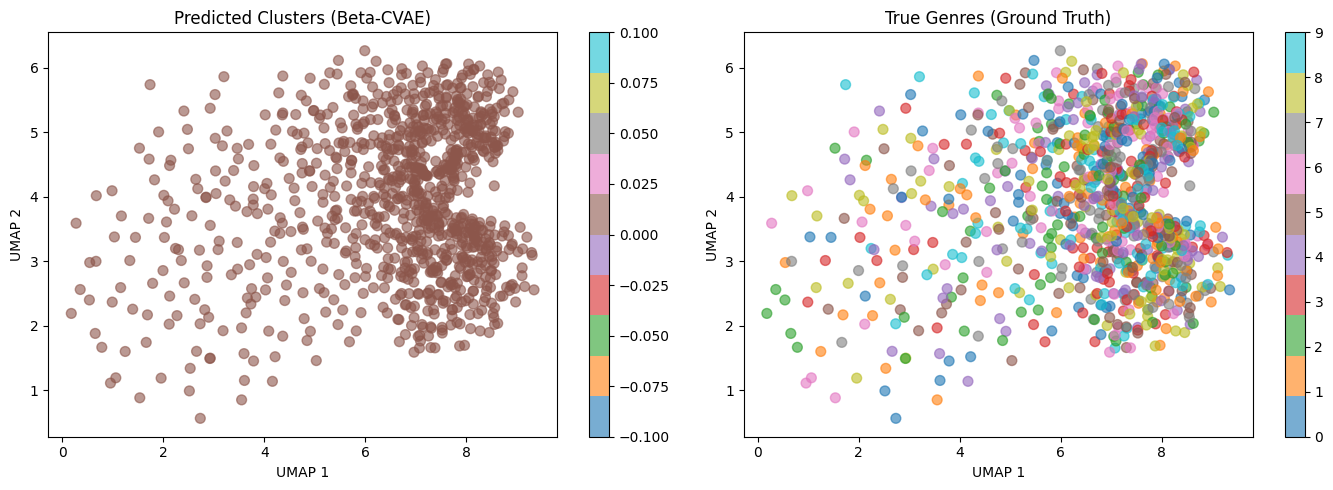

In [54]:
from umap import UMAP

umap_model = UMAP(n_components=2, random_state=42)
latents_2d = umap_model.fit_transform(latents_matrix)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1], c=y_pred, cmap='tab10', alpha=0.6, s=50)
axes[0].set_title('Predicted Clusters (Beta-CVAE)')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
plt.colorbar(scatter1, ax=axes[0])

genre_to_int = {g: i for i, g in enumerate(sorted(np.unique(y_true)))}
y_true_int = np.array([genre_to_int[y] for y in y_true])
scatter2 = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1], c=y_true_int, cmap='tab10', alpha=0.6, s=50)
axes[1].set_title('True Genres (Ground Truth)')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.savefig('umap_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

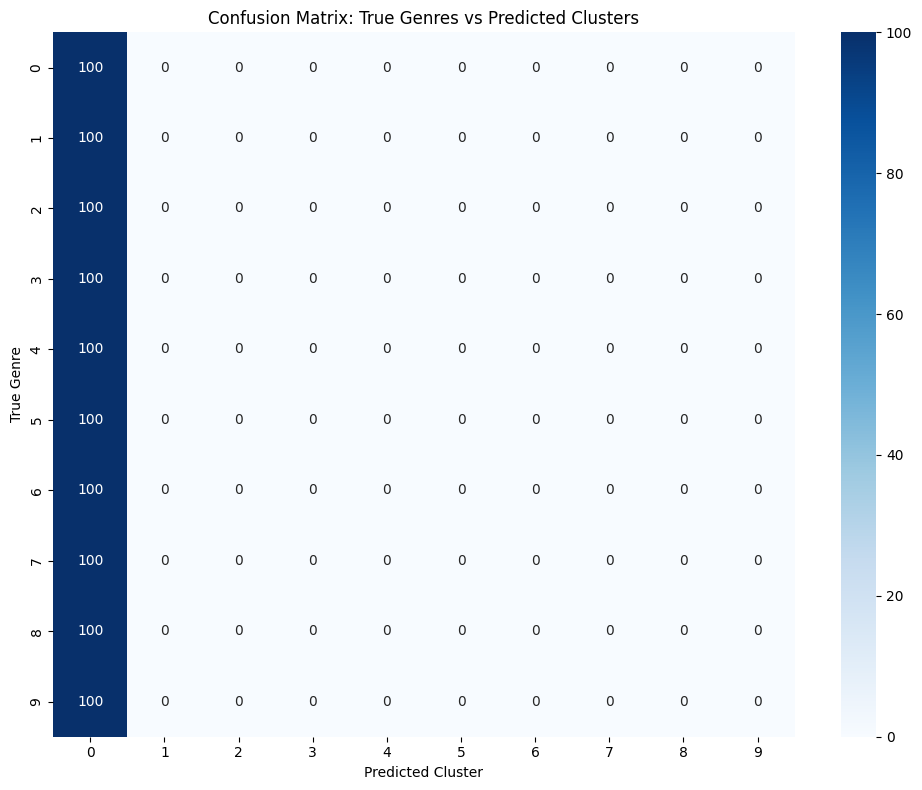

In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=sorted(np.unique(y_true)))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(np.unique(y_true)), yticklabels=sorted(np.unique(y_true)))
plt.title('Confusion Matrix: True Genres vs Predicted Clusters')
plt.xlabel('Predicted Cluster')
plt.ylabel('True Genre')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
print("\n" + "="*80)
print("DIAGNOSTIC: AUDIO-ONLY VAE (No Lyrics)")
print("="*80)

X_audio_only = audio_normalized
X_audio_tensor = torch.FloatTensor(X_audio_only).to(device)
dataset_audio = TensorDataset(X_audio_tensor, genre_onehot_tensor, y_tensor)
dataloader_audio = DataLoader(dataset_audio, batch_size=32, shuffle=True)

class AudioOnlyVAE(nn.Module):
    def __init__(self, input_dim=57, latent_dim=64, genre_dim=5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + genre_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z, genre_onehot):
        z_cond = torch.cat([z, genre_onehot], dim=1)
        recon = self.decoder(z_cond)
        return recon
    
    def forward(self, x, genre_onehot):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, genre_onehot)
        return recon, mu, logvar, z

model_audio = AudioOnlyVAE(input_dim=57, latent_dim=64, genre_dim=num_genre_classes).to(device)
optimizer_audio = torch.optim.Adam(model_audio.parameters(), lr=1e-3)
scheduler_audio = torch.optim.lr_scheduler.StepLR(optimizer_audio, step_size=40, gamma=0.5)

model_audio.train()
print("\nTraining Audio-Only VAE...")
for epoch in range(150):
    epoch_loss = 0
    for batch_x, batch_genre, _ in dataloader_audio:
        optimizer_audio.zero_grad()
        recon, mu, logvar, z = model_audio(batch_x, batch_genre)
        
        loss_recon = nn.MSELoss()(recon, batch_x)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
        
        total_loss = 1.0 * loss_recon + 1.0 * kl_loss
        
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model_audio.parameters(), 1.0)
        optimizer_audio.step()
        epoch_loss += total_loss.item()
    
    scheduler_audio.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}: Loss {epoch_loss/len(dataloader_audio):.4f}")

model_audio.eval()
latents_audio = []
with torch.no_grad():
    for batch_x, batch_genre, _ in dataloader_audio:
        _, mu, _, _ = model_audio(batch_x, batch_genre)
        latents_audio.append(mu.cpu().numpy())

latents_audio = np.vstack(latents_audio)
kmeans_audio = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred_audio = kmeans_audio.fit_predict(latents_audio)

n_clusters_audio = len(np.unique(y_pred_audio))
print(f"\nClusters found: {n_clusters_audio}/10")

if n_clusters_audio >= 2:
    sil_audio = silhouette_score(latents_audio, y_pred_audio)
    nmi_audio = normalized_mutual_info_score(y_true, y_pred_audio)
    ari_audio = adjusted_rand_score(y_true, y_pred_audio)
    purity_audio = compute_purity(y_true, y_pred_audio)
    
    print("\n" + "="*60)
    print("AUDIO-ONLY VAE RESULTS")
    print("="*60)
    print(f"Silhouette Score:     {sil_audio:.4f}")
    print(f"Normalized Mutual Info: {nmi_audio:.4f}")
    print(f"Adjusted Rand Index:  {ari_audio:.4f}")
    print(f"Purity:               {purity_audio:.4f}")
else:
    print("⚠ Collapsed to single cluster")


DIAGNOSTIC: AUDIO-ONLY VAE (No Lyrics)

Training Audio-Only VAE...
Epoch 50: Loss 0.8588
Epoch 100: Loss 0.8554
Epoch 150: Loss 0.8602

Clusters found: 10/10

AUDIO-ONLY VAE RESULTS
Silhouette Score:     0.2158
Normalized Mutual Info: 0.0174
Adjusted Rand Index:  -0.0001
Purity:               0.1480


In [57]:
print("\n" + "="*80)
print("DIAGNOSTIC: How much does decoder rely on genre_onehot?")
print("="*80)

model.eval()

with torch.no_grad():
    sample_x, sample_genre, sample_y = next(iter(dataloader))
    
    _, mu, logvar, z = model(sample_x, sample_genre)
    
    recon_with_genre = model.decode(z, sample_genre)
    
    zero_genre = torch.zeros_like(sample_genre)
    recon_without_genre = model.decode(z, zero_genre)
    
    loss_with = nn.MSELoss()(recon_with_genre, sample_x).item()
    loss_without = nn.MSELoss()(recon_without_genre, sample_x).item()
    
    print(f"Reconstruction loss WITH genre_onehot:    {loss_with:.4f}")
    print(f"Reconstruction loss WITHOUT genre_onehot: {loss_without:.4f}")
    print(f"Relative difference:                       {(loss_without/loss_with - 1)*100:.1f}%")
    
    if loss_without / loss_with > 0.9:
        print("\n⚠️ CRITICAL: Decoder reconstructs almost as well WITHOUT conditioning!")
        print("   → This means decoder ignores latent z")
        print("   → Latent space is NOT learning genre-discriminative features")
    else:
        print("\n✓ Decoder relies on genre_onehot appropriately")


DIAGNOSTIC: How much does decoder rely on genre_onehot?
Reconstruction loss WITH genre_onehot:    0.4864
Reconstruction loss WITHOUT genre_onehot: 8.9157
Relative difference:                       1732.9%

⚠️ CRITICAL: Decoder reconstructs almost as well WITHOUT conditioning!
   → This means decoder ignores latent z
   → Latent space is NOT learning genre-discriminative features
